In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("supermarket.csv")


In [5]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
df.describe()


,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


<Axes: ylabel='Branch'>

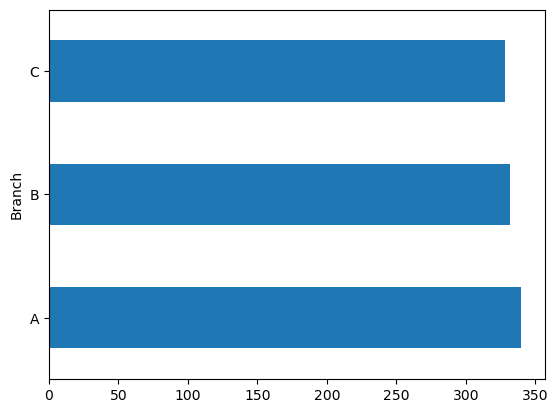

In [17]:
df.Branch.value_counts().plot.barh()

In [18]:
line_df = df[df.Branch == 'Product line']
Quantity_df = df[df.Branch == 'Quantity']
Payment_df = df[df.Branch == 'Payment']
Time_df = df[df.Branch == 'Time']

In [10]:
print(f'Line df{line_df.shape}')
print(f'Quantity df{Quantity_df.shape}')
print(f'Payment df{Payment_df.shape}')
print(f'Time df{Time_df.shape}')

Line df(0, 17)
Quantity df(0, 17)
Payment df(0, 17)
Time df(0, 17)


In [15]:
def create_sale(df):
    
    # Drop columns 'line' and 'Unnamed : 0' before transpose, if they exist
    df_clean = df.drop(['line', 'Unnamed : 0'], axis=1, errors='ignore')
    # Transpose, sum along columns (original rows), to get total sales per line
    sale_df = df_clean.T.sum(axis=1).to_frame(name="value")
    # Remove rows where all values are zero (assuming sale_df here)
    sale_df = sale_df[(sale_df['value'] != 0)]
    # Sort descending by value
    sale_df = sale_df.sort_values(by='value', ascending=False, inplace=False)
    return sale_df

In [43]:
#line_sale_df = create_sale(line_df)
#line_sale_df.head(10).plot.barh()

In [28]:
feature_df = df.drop(['cogs','Gender','City'],axis = 1)
labels_df = df.Branch
feature_df.head()

,Invoice ID,Branch,Customer type,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,gross margin percentage,gross income,Rating
0,750-67-8428,A,Member,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,4.761905,26.1415,9.1
1,226-31-3081,C,Normal,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,4.761905,3.8200,9.6
2,631-41-3108,A,Normal,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,4.761905,16.2155,7.4
3,123-19-1176,A,Member,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,4.761905,23.2880,8.4
4,373-73-7910,A,Normal,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,4.761905,30.2085,5.3


In [33]:
#SMOTE only work with numbric data
#from imblearn.over_sampling import SMOTE
#oversample = SMOTE()
#transformed_feature_df, transformed_label_df = oversample.fit_resample(feature_df, labels_df)
#print(f'new label count : {transformeed_label_df.value_counts()}')
#print(f'old label count: {labels_df.value_counts}')

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [40]:
#X_train, X_test, y_train, y_test = train_test_split(tranformed_feature_df,transformeed_label_df,test_size = 0.3)

In [41]:
#lr = LogisticRegression(multi_class= 'ovr', solver = 'libliner')
#model = lr.fit(X_trian,np.ravel(y_trian))

#accuracy = model.score(X_test, y_test)
#print("Accuracy is () :".format(accuracy))

In [ ]:
#print(f'Sale : {X_test.iloc[50][X_test.iloc[50]!=0].keys()}')
#print(f'Line : {y_test.iloc[50]}')

In [35]:
#Data Preparation Model Building and Performance Evalution
dataset = pd.read_csv('Position_Salaries.csv')

In [36]:
dataset.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [37]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [38]:
dataset.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [39]:
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 1:2].values

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state  = 0)

In [41]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

In [42]:
def viz_linear():
    plt.scatter(X,y, color = 'red')
    plt.plot(X, lin_reg.predict(X), color = 'blue')
    plt.title("Liner Regression model")
    plt.xlabel("Salary Data")
    plt.ylabel("Salary")
    plt.show()

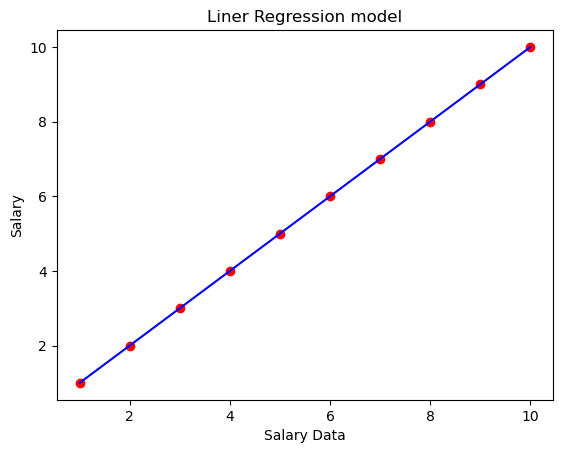

In [43]:
viz_linear()

In [60]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly  = poly_reg.fit_transform(X)
poly_reg.fit(X_poly, y)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, y)

LinearRegression()

In [63]:
def viz_polymonial():
    plt.scatter(X,y, color = 'red')
    plt.plot(X, pol_reg.predict(poly_reg.fit_transform(X)), color = 'blue')
    plt.title("Polymonial Regression model")
    plt.xlabel("Salary Data")
    plt.ylabel("Salary")
    plt.show()

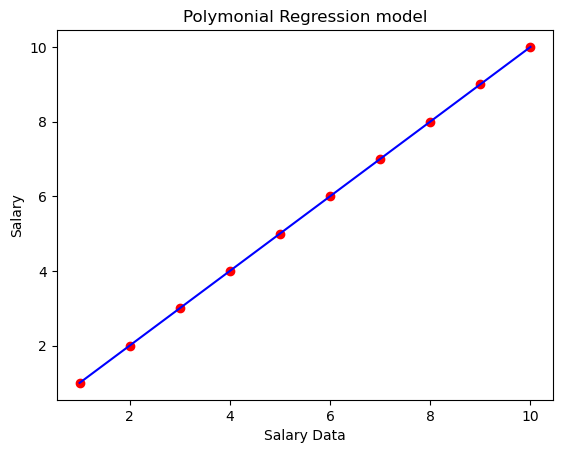

In [64]:
viz_polymonial()

In [90]:
lin_reg.predict([[5.5]])

array([[5.5]])

In [ ]:
lin_reg.predict(poly.fit_transform([[5.5]]))

In [64]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
df = pd.read_csv("house.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [51]:
df.drop(columns=['country'], inplace=True)

In [52]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4600 non-null   float64
 1   bedrooms       4600 non-null   float64
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 467.3 KB


In [54]:
x = df.drop(["price"], axis = 1)
y = df['price']

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.25, random_state = 42)

In [56]:
Ridge_model = Ridge(alpha = 1).fit(x_train, y_train)
Ridge_model.intercept_

5135476.311852976

In [57]:
y_pred = Ridge_model.predict(x_test)
np.sqrt(mean_squared_error(y_test,y_pred))

896918.4089602672

In [58]:
Ridge_model.coef_

array([-6.91288012e+04,  3.56578857e+04,  1.89107879e+02, -4.80817058e-01,
        6.84361046e+04,  3.60461558e+05,  4.36711821e+04,  3.00685937e+04,
        1.00226026e+02,  8.88823034e+01, -2.67254152e+03,  5.52653153e+00])

In [59]:
r2_score(y_test, y_pred)

0.04493944024444452

In [61]:
from sklearn.model_selection import GridSearchCV
cv = RepeatedKFold(n_splits = 10, n_repeats = 3, random_state = 1)

grid = dict()
grid['alpha'] = np.arange(0, 1, 0.1)
model = Ridge()
search = GridSearchCV(model, grid, scoring = 'neg_mean_absolute_error', cv = cv, n_jobs = -1)

results = search.fit(x_train, y_train)
print('price : %.3f' % results.best_score_)
print('Config : %s' % results.best_params_)


/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.68973e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.23577e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.87133e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.41928e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/

price : -159435.082
Config : {'alpha': 0.9}


In [65]:
Ridge_model = Ridge(alpha = 0.7,).fit(x_train, y_train)
y_pred = Ridge_model.predict(x_test)
np.sqrt( mean_squared_error(y_test, y_pred))

896921.0330487412

In [66]:
r2_score(y_test, y_pred)

0.04493385184967447

In [69]:
pd.Series(Ridge_model.coef_, index = x_train.columns)

bedrooms         -69112.579983
bathrooms         35668.169080
sqft_living         189.091280
sqft_lot             -0.480811
floors            68467.282194
waterfront       365483.874660
view              43490.834105
condition         30112.547629
sqft_above          100.205800
sqft_basement        88.886119
yr_built          -2672.114529
yr_renovated          5.527000
dtype: float64

In [93]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV

In [94]:
fg = pd.read_csv("Hitters.csv")

In [95]:
fg.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [96]:
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

In [97]:
fg['Salary'].fillna(fg['Salary'].median(skipna = True), inplace = True)
fg.isna().sum()

/tmp/ipykernel_23107/1102063401.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fg['Salary'].fillna(fg['Salary'].median(skipna = True), inplace = True)


Unnamed: 0    0
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary        0
NewLeague     0
dtype: int64

In [99]:
dms = pd.get_dummies(fg[["League","Division","NewLeague"]], drop_first = True)

In [105]:
y = fg['Salary']
x_= fg.drop(['Unnamed: 0','Salary','League','Division', 'NewLeague'], axis = 1).astype('float64')
x = pd.concat([x_, dms[['League_N','Division_W', 'NewLeague_N']]], axis = 1)


In [106]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.25, random_state = 42)

In [107]:
lasso_model = Lasso().fit(x_train, y_train)
lasso_model.intercept_

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.923e+06, tolerance: 3.853e+03
  model = cd_fast.enet_coordinate_descent(


342.8733925858777

In [109]:
lasso_model.coef_

array([-1.98558949e+00,  5.50494749e+00,  4.79612807e+00,  1.02123896e-01,
       -8.11521080e-01,  4.87004116e+00, -9.97808288e+00, -2.19391227e-01,
        6.16237616e-01,  9.03214960e-03,  8.73990383e-01,  7.84172593e-01,
       -8.13423037e-01,  1.83989460e-01,  4.04846687e-01, -4.08650952e+00,
        2.67092023e+01, -1.11463261e+02, -0.00000000e+00])

In [110]:
y_pred = lasso_model.predict(x_test)
np.sqrt(mean_squared_error(y_test, y_pred))

345.6190692407428

In [111]:
r2_score(y_test, y_pred)

0.3657513009571691

In [117]:
lasso_cv_model = LassoCV(alphas = np.random.randint(0, 1000, 100), cv = 10, max_iter = 10000, n_jobs = -1).fit(x_train, y_train)

In [118]:
lasso_cv_model.alpha_

12

In [121]:
lasso_turned = Lasso().set_params(alpha = 14).fit(x_train, y_train)
y_pred_turned = lasso_turned.predict(x_test)
np.sqrt(mean_squared_error(y_test, y_pred_turned))

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+06, tolerance: 3.853e+03
  model = cd_fast.enet_coordinate_descent(


346.70839160783527

In [125]:
pd.Series(lasso_turned.coef_, index = x_train.columns)

AtBat          -1.918086
Hits            5.126820
HmRun           2.443879
Runs            0.295663
RBI            -0.000000
Walks           4.821499
Years          -3.879546
CAtBat         -0.263819
CHits           0.734330
CHmRun          0.132193
CRuns           0.864787
CRBI            0.735014
CWalks         -0.786518
PutOuts         0.178432
Assists         0.382404
Errors         -2.613340
League_N        0.000000
Division_W    -55.486277
NewLeague_N     0.000000
dtype: float64

In [1]:
#Apply Naive Bayes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

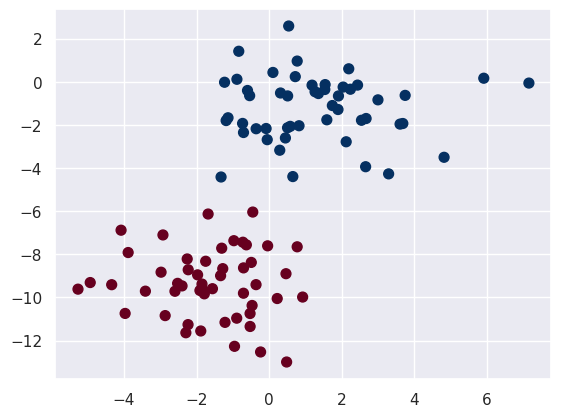

In [3]:
from sklearn.datasets import make_blobs
x, y = make_blobs(100,2, centers = 2, random_state = 2, cluster_std = 1.5)
plt.scatter(x[:,0],x[:,1], c = y, s = 50, cmap = 'RdBu')

In [4]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(x,y)

GaussianNB()

In [14]:
rng = np.random.RandomState(0)
xnew = [-6,-14]+[ 14,18] * rng.rand(2000,2)
ynew = model.predict(xnew)

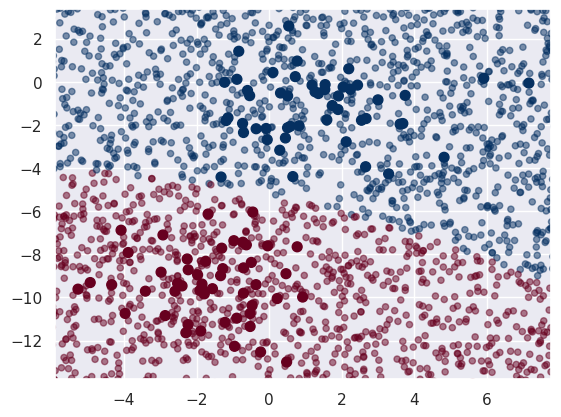

In [15]:
plt.scatter(x[:,0],x[:,1], c = y, s = 50, cmap = 'RdBu')
lim = plt.axis()
plt.scatter(xnew[:,0], xnew[:,1], c = ynew, s = 20, cmap = 'RdBu', alpha = 0.5)
plt.axis(lim);

In [16]:
yprob = model.predict_proba(xnew)
yprob[-8:].round(2)

array([[0.89, 0.11],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.15, 0.85]])

In [1]:
#Stochastic Gradient Descent

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [3]:
bc = datasets.load_breast_cancer()
x = bc.data
y = bc.target

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size  = 0.3, random_state  = 42, stratify = y)

In [13]:
import numpy as np

class CustomPerceptron(object):
    def __init__(self, n_iterations=100, random_state=1, learning_rate=0.01):
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.learning_rate = learning_rate

    def fit(self, x, y):
        rgen = np.random.RandomState(self.random_state)
        self.coef_ = rgen.normal(loc=0.0, scale=0.1, size=1 + x.shape[1])
        
        for _ in range(self.n_iterations):
            for xi, expected_value in zip(x, y):
                predicted_value = self.predict(xi)
                error = expected_value - predicted_value
                self.coef_[1:] += self.learning_rate * error * xi
                self.coef_[0] += self.learning_rate * error  # Bias update

    def activation(self, x):
        return np.dot(x, self.coef_[1:]) + self.coef_[0]

    def predict(self, x):
        output = self.activation(x)
        return np.where(output >= 0.0, 1, 0)

    def score(self, x, y):
        misclassified_data_count = 0
        for xi, target in zip(x, y):
            output = self.predict(xi)
            if target != output:
                misclassified_data_count += 1
        total_data_count = len(x)
        self.score_ = (total_data_count - misclassified_data_count) / total_data_count
        return self.score_


In [14]:
n_iterantions = 100
learning_rate = 0.11

In [15]:
prcptrn = CustomPerceptron()
prcptrn.fit(x_train, y_train)

In [16]:
print(prcptrn.score(x_test, y_test))
prcptrn.score(x_train, y_train)

0.9064327485380117


0.9271356783919598

In [17]:
#KNN

In [18]:
df = pd.read_csv("Social_Network_Ads.csv")

In [19]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [21]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [26]:
gender = pd.get_dummies(df['Gender'], drop_first = True)
df = pd.concat([df, gender], axis = 1)

In [27]:
df.drop(['Gender'], axis = 1, inplace = True)

In [28]:
x = df[['Age','EstimatedSalary','Male']]
y = df['Purchased']

In [31]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
Scaler.fit(x)

StandardScaler()

In [41]:
Scaled_features = Scaler.transform(x)
Scaled_features

array([[-1.78179743, -1.49004624,  1.02020406],
       [-0.25358736, -1.46068138,  1.02020406],
       [-1.11320552, -0.78528968, -0.98019606],
       ...,
       [ 1.17910958, -1.46068138, -0.98019606],
       [-0.15807423, -1.07893824,  1.02020406],
       [ 1.08359645, -0.99084367, -0.98019606]])

In [42]:
df_feat = pd.DataFrame(Scaled_features, columns = x.columns)
df_feat.head()

,Age,EstimatedSalary,Male
0,-1.781797,-1.490046,1.020204
1,-0.253587,-1.460681,1.020204
2,-1.113206,-0.785290,-0.980196
3,-1.017692,-0.374182,-0.980196
4,-1.781797,0.183751,1.020204


In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( Scaled_features, y, test_size=0.2, random_state=42)

In [48]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [49]:
pred = knn.predict(x_test)

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(y_test, pred)

array([[50,  2],
       [ 7, 21]])

In [51]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [52]:
# Decision Tree

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data")

In [5]:
df.head()

,B,1,1.1,1.2,1.3
0,R,1,1,1,2
1,R,1,1,1,3
2,R,1,1,1,4
3,R,1,1,1,5
4,R,1,1,2,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   B       624 non-null    object
 1   1       624 non-null    int64 
 2   1.1     624 non-null    int64 
 3   1.2     624 non-null    int64 
 4   1.3     624 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 24.5+ KB


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
x = df.drop('B', axis = 1)
y = df[['B']]

In [9]:
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [11]:
from sklearn.tree import DecisionTreeClassifier
clf_model = DecisionTreeClassifier(criterion = 'gini', random_state = 42, max_depth = 3, min_samples_leaf = 5)

In [13]:
clf_model.fit(x_train, y_train)
y_pred = clf_model.predict(x_test)

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 0  7  5]
 [ 0 60 27]
 [ 0 15 74]]
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.73      0.69      0.71        87
           R       0.70      0.83      0.76        89

    accuracy                           0.71       188
   macro avg       0.48      0.51      0.49       188
weighted avg       0.67      0.71      0.69       188



/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
target = list(df['B'].unique())
feature_names = list(x.columns)

In [20]:
from sklearn.tree import export_text
r = export_text(clf_model, feature_names=feature_names)
print(r)

|--- 1 <= 2.50
|   |--- 1.3 <= 2.50
|   |   |--- 1.2 <= 2.50
|   |   |   |--- class: L
|   |   |--- 1.2 >  2.50
|   |   |   |--- class: R
|   |--- 1.3 >  2.50
|   |   |--- 1.2 <= 1.50
|   |   |   |--- class: R
|   |   |--- 1.2 >  1.50
|   |   |   |--- class: R
|--- 1 >  2.50
|   |--- 1.1 <= 2.50
|   |   |--- 1.2 <= 1.50
|   |   |   |--- class: L
|   |   |--- 1.2 >  1.50
|   |   |   |--- class: R
|   |--- 1.1 >  2.50
|   |   |--- 1.3 <= 3.50
|   |   |   |--- class: L
|   |   |--- 1.3 >  3.50
|   |   |   |--- class: L



Random Forest

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor  # Corrected typo here
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("petrol_consumption.csv")

In [3]:
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-null     int64  
 3   Population_Driver_licence(%)  48 non-null     float64
 4   Petrol_Consumption            48 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 KB


In [12]:
x = df.iloc[:,0:4].values
y = df.iloc[:,4].values

In [18]:
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [15]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
y_test = sc.fit_transform(x_test) 

In [16]:
reg = RandomForestRegressor(n_estimators = 20, random_state = 0)
reg.fit(x_train, y_train)
y_pred = reg.predict(x_test)

In [20]:
print('Train MAE:' ,mean_absolute_error(y_train, reg.predict(x_train)) )
print('Train RSME:' , np.sqrt(mean_squared_error(y_train, reg.predict(x_train))))
print('R Square:' , r2_score(y_train, reg.predict(x_train)))

Train MAE: 69.6969696969697
Train RSME: 97.44471004190792
R Square: -0.156297626723364


In [21]:
print('Train MAE:' ,mean_absolute_error(y_test, reg.predict(x_test)) )
print('Train RSME:' , np.sqrt(mean_squared_error(y_test, reg.predict(x_test))))
print('R Square:' , r2_score(y_test, reg.predict(x_test)))

Train MAE: 109.13333333333334
Train RSME: 145.44363398467002
R Square: -0.006045722967634504


In [1]:
#Boruta

In [7]:
pip install boruta

Note: you may need to restart the kernel to use updated packages.


In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from boruta import BorutaPy
from sklearn.metrics import accuracy_score

In [42]:
URL = "https://raw.githubusercontent.com/Aditya1001001/English-Premier-League/master/pos_modelling_data.csv"
df = pd.read_csv(URL)

In [43]:
df.head()

,Position,Clean sheets,Goals conceded,Tackles,Tackle success %,Blocked shots,Interceptions,Clearances,Recoveries,Successful 50/50s,...,Shots,Shooting accuracy %,Saves,Penalties saved,age,value_eur,overall,Arial Saves,Duels %,Aerial battles %
0,Midfielder,0.0,0.0,4.0,100,0.0,1.0,0.0,9.0,4.0,...,2.0,50,0.0,0.0,21,4400000,72,0.0,46.153846,25.000000
1,Defender,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,22,10500000,77,0.0,0.000000,0.000000
2,Forward,0.0,0.0,10.0,0,11.0,1.0,19.0,0.0,0.0,...,42.0,36,0.0,0.0,19,7500000,73,0.0,0.000000,0.000000
3,Midfielder,0.0,0.0,9.0,56,3.0,9.0,14.0,40.0,12.0,...,10.0,30,0.0,0.0,31,4800000,74,0.0,55.384615,58.333333
4,Midfielder,0.0,0.0,22.0,59,5.0,14.0,0.0,58.0,6.0,...,11.0,18,0.0,0.0,28,0,83,0.0,40.869565,36.666667


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Position             1793 non-null   object 
 1   Clean sheets         1793 non-null   float64
 2   Goals conceded       1793 non-null   float64
 3   Tackles              1793 non-null   float64
 4   Tackle success %     1793 non-null   int64  
 5   Blocked shots        1793 non-null   float64
 6   Interceptions        1793 non-null   float64
 7   Clearances           1793 non-null   float64
 8   Recoveries           1793 non-null   float64
 9   Successful 50/50s    1793 non-null   float64
 10  Own goals            1793 non-null   float64
 11  Assists              1793 non-null   int64  
 12  Passes               1793 non-null   int64  
 13  Passes per match     1793 non-null   float64
 14  Big chances created  1793 non-null   float64
 15  Crosses              1793 non-null   f

In [52]:
x = df.drop('Position', axis = 1)
y = df[['Position']]
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [20]:
#df.drop(columns=['Goalkeeper'], inplace=True)

In [53]:
rf_all_features = RandomForestClassifier(n_estimators = 1000, random_state = 1, max_depth = 5)
rf_all_features.fit(x_train, y_train)
accuracy_score(y_test,rf_all_features.predict(x_test))

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.7379182156133829

In [54]:
fre = RandomForestClassifier(random_state = 1, n_estimators = 1000, max_depth = 5)
boruta_selector = BorutaPy(fre, n_estimators = 'auto', verbose = 2,random_state = 1)
boruta_selector.fit(np.array(x_train), np.array(y_train))

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	34
Rejected: 	0


/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	34
Rejected: 	0


/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	98 / 100
Confirmed: 	31
Tentative: 	1
Rejected: 	2


/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	99 / 100
Confirmed: 	31
Tentative: 	1
Rejected: 	2


BorutaPy finished running.

Iteration: 	100 / 100
Confirmed: 	31
Tentative: 	0
Rejected: 	3


BorutaPy(estimator=RandomForestClassifier(max_depth=5, n_estimators=160,
                                          random_state=RandomState(MT19937) at 0x7FA5F0B51A40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7FA5F0B51A40, verbose=2)

In [32]:
print("Ranking:", boruta_selector.ranking_)
print("No of significant features:",boruta_selector.n_features_)

Ranking: [1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 4 1 1 1 1 1 1 1 2 1 1 1 1 1 1]
No of significant features: 31


In [55]:
selected_rf_features = pd.DataFrame({'Features' : list(x_train.columns), "Ranking": boruta_selector.ranking_})
selected_rf_features.sort_values(by = 'Ranking')

,Features,Ranking
0,Clean sheets,1
31,Arial Saves,1
30,overall,1
29,value_eur,1
28,age,1
26,Saves,1
25,Shooting accuracy %,1
24,Shots,1
23,Goals per match,1
22,Goals,1


In [56]:
x_imp_train = boruta_selector.transform(np.array(x_train))
x_imp_test = boruta_selector.transform(np.array(x_train))

In [57]:
rf_boruta = RandomForestClassifier(random_state = 1, n_estimators = 1000, max_depth = 5)
rf_boruta.fit(x_imp_train, y_train)

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=5, n_estimators=1000, random_state=1)

In [1]:
#accuracy_score(y_test, rf_boruta.predict(x_imp_test))

Support Vector Machine

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import svm

In [15]:
fg = pd.read_csv('heart.csv')

In [8]:
fg.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
fg.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Text(0.5, 1.0, 'Age- Cholestrol plot')

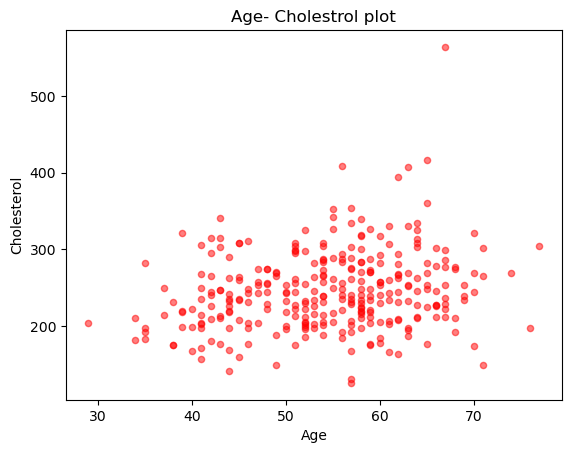

In [17]:
fg.plot(kind = 'scatter', x = "age", y = 'chol', alpha = 0.5, color = 'red')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age- Cholestrol plot')

In [10]:
fg_new = pd.get_dummies(fg, columns = ['cp','thal'], drop_first = True)

In [11]:
x = fg_new.drop('fbs', axis = 1)
y = fg_new.fbs

In [12]:
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size = 0.4, random_state = 100)

In [16]:
from sklearn.model_selection import GridSearchCV
ml = svm.SVC()
para_grid = {'C':[1,10,100,1000], 'gamma' : [1, 0.1, 0.01, 0.001], 'kernel' : ['rbf']}
grid = GridSearchCV(ml, para_grid, refit = True, verbose = 1, cv = 5, n_jobs = -1)
grid_search = grid.fit(x_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [18]:
print(grid_search.best_params_)

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}


In [20]:
accuracy = grid_search.best_score_

In [21]:
accuracy

0.8785285285285285

In [22]:
y_test_hat = grid.predict(x_test)

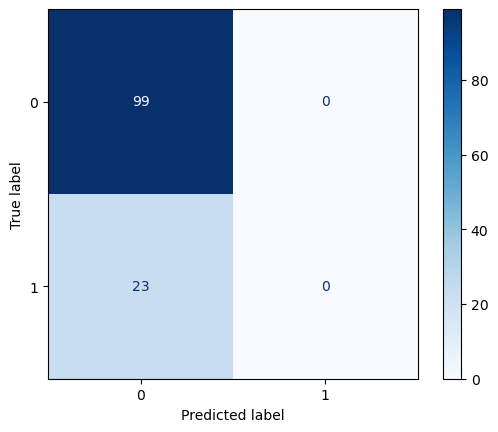

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
confusion_mat = confusion_matrix(y_test, y_test_hat)
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_mat, display_labels = grid.classes_)
disp.plot(cmap = plt.cm.Blues, ax = plt.gca())
plt.show()

In [28]:
print(classification_report(y_test, y_test_hat))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        99
           1       0.00      0.00      0.00        23

    accuracy                           0.81       122
   macro avg       0.41      0.50      0.45       122
weighted avg       0.66      0.81      0.73       122



/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
